In [1]:
import scipy
from scipy.special import *
import numpy as np
import os
#import sub_spac_das

from tqdm.notebook import tqdm,trange

import matplotlib.pyplot as plt
from matplotlib import colors
#----------------------------------------
# parameter
#----------------------------------------
# savedir
savedir = "./out_test_SeaFOAM"
# filedir
filedir = "./data_cross-spectra"




In [2]:
def exx_ray_spac_nocoef(f,dist,cr):
        kr =  (2.0 * np.pi * f )/cr
        xr = dist * kr

        ray_spac_nocoef =  (kr**2)  * ( 3.0 * jn(0, xr)  - 4.0* jn(2, xr) + jn(4, xr) ) 

        return ray_spac_nocoef, kr

In [3]:
def grid_search_fitting_rayleigh(f,cross_obs,distlist,phase_search):

        nccr = len(cross_obs)
        G = np.zeros([nccr,1],dtype=np.float64)

        ngrid = len(phase_search)
        cost_list = np.zeros([ngrid],dtype=np.float64)
        Amp_search = np.zeros([ngrid],dtype=np.float64)
        syn_spac_search = np.zeros([ngrid,nccr],dtype=np.float64)
        for ip in range(ngrid):


            cR = phase_search[ip]
            #------------------------------------       
            # MK G
            #------------------------------------ 

            ray_spac_nocoef,kr = exx_ray_spac_nocoef(f,distlist,cR)
            G[:,0] = ray_spac_nocoef

            #------------------------------------       
            # Inverted A and calc syn ray_spac
            #------------------------------------ 

            A = np.linalg.lstsq(G, cross_obs,rcond=None)[0]
            Amp_search[ip] = A[0]
            syn_ray_spac = np.dot(G,A)
            
            syn_spac_search[ip,:] = syn_ray_spac[:]
            
            delta =( cross_obs  - syn_ray_spac) 

            cost = np.dot(delta,delta)/nccr 
            cost_list[ip] = cost

        #-----------------------------------------
        # return data
        #-----------------------------------------
        
        return cost_list,Amp_search,syn_spac_search

In [31]:
#cross_real.shape

In [1130]:
stack = np.load('../npy/9cha_2022360.npy')

for ii,i in enumerate(np.arange(0,2048*9,2048)):

    if ii == 8:

       stack_tem = stack[i:i+2048,:]/384

In [1176]:
# start_ch = 0
# end_ch = 200

# vs_ch = 200

# start_ch = 200
# end_ch = 400

###-----------------

# start_ch = 200
# end_ch = 410

# vs_ch = 410

# start_ch = 410
# end_ch = 610

###-----------------

# start_ch = 400
# end_ch = 615

# vs_ch = 615

# start_ch = 615
# end_ch = 800

###-----------------

# start_ch = 600
# end_ch = 820

# vs_ch = 820

# start_ch = 820
# end_ch = 1020

###-----------------

# start_ch = 800
# end_ch = 1025

# vs_ch = 1025

# start_ch = 1025
# end_ch = 1250

###-----------------

# start_ch = 1000
# end_ch = 1230

# vs_ch = 1230

# start_ch = 1230
# end_ch = 1500

###-----------------

# start_ch = 1135
# end_ch = 1435

# vs_ch = 1435

# start_ch = 1435
# end_ch = 1750

###-----------------

# start_ch = 1240
# end_ch = 1640

# vs_ch = 1640

# start_ch = 1640
# end_ch = 1840
###-----------------


# start_ch = 1555
# end_ch = 1845

vs_ch = 1845

start_ch = 1845
end_ch = 2048



In [1177]:
%matplotlib inline
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

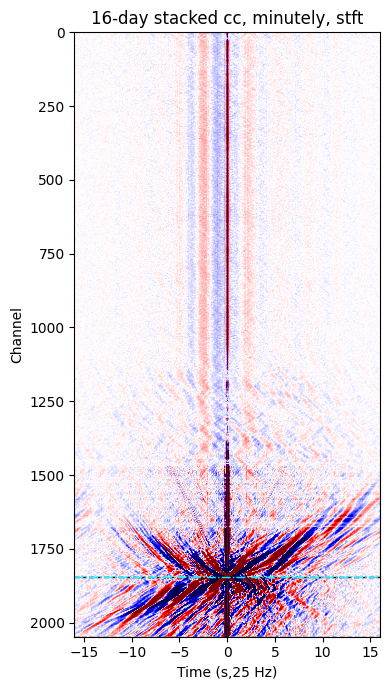

In [1178]:
%matplotlib inline

plt.clf()
plt.figure(figsize=(4,7),dpi=100)
    
v = np.std(stack_tem)#/100

plt.imshow(stack_tem[:,:],vmin=-v,vmax=v,extent=[-16,16,2048,0],aspect='auto',
#plt.imshow(stack_tem[625:725,::],vmin=-v,vmax=v,
#plt.imshow(stack_tem[225:1025,0:],vmin=-v,vmax=v,
           cmap='seismic')
#plt.xticks(np.arange(399-15*25,399+15*25,100),[round(n) for n in np.arange(0-15*25,0+15*25,100) / 25])
#plt.yticks(np.arange(0,2048,250),np.arange(0,2048,250)*5)
#plt.tick_params(axis='x', labelsize=8) 

# c = 500
# t = np.arange(-16,16,1)
# xc = 615 + c*t / (5.1*5)
# plt.plot(t,xc)

# c = 1000
# t = np.arange(-16,16,1)
# xc = 615 + c*t / (5.1*5)
# plt.plot(t,xc)

# c = 2000
# t = np.arange(-16,16,1)
# xc = 615 + c*t / (5.1*5)
# plt.plot(t,xc)

plt.axhline(start_ch, color='k', linestyle='--',linewidth=1)

plt.axhline(end_ch, color='k', linestyle='--',linewidth=1)

plt.axhline(vs_ch, color='cyan', linestyle='-.',linewidth=1)


plt.xlabel('Time (s,25 Hz)')
plt.ylabel('Channel')
#plt.colorbar(shrink=0.7)
plt.title('16-day stacked cc, minutely, stft')
plt.tight_layout()

plt.ylim([2048,0])

#plt.savefig('../results/stack/figures/16days/selected_ch_'+str(ii)+'_16_days_stack.jpg')
plt.show()
plt.close()

In [1179]:
stack_tem.shape

(2048, 800)

In [1180]:
## Quadrant 1

# data = stack_tem.copy()[start_ch:end_ch,400:]

## Quadrant 4

# data = stack_tem.copy()[start_ch:end_ch,399::-1]


## Quadrant 2

# data = stack_tem.copy()[start_ch:end_ch,400:]

## Quadrant 3

data = stack_tem.copy()[start_ch:end_ch,399::-1]



In [1181]:
data = data - np.mean(data, axis=-1, keepdims=True)  # (nx, nt)
data = data - np.mean(data, axis=-2, keepdims=True)  # (nx, nt)
data = data - np.median(data, axis=-2, keepdims=True)

data *= scipy.signal.tukey(data.shape[1], alpha=0.1)
data *= scipy.signal.tukey(data.shape[0], alpha=0.1).reshape(-1, 1)

In [1182]:
data.shape

(203, 400)

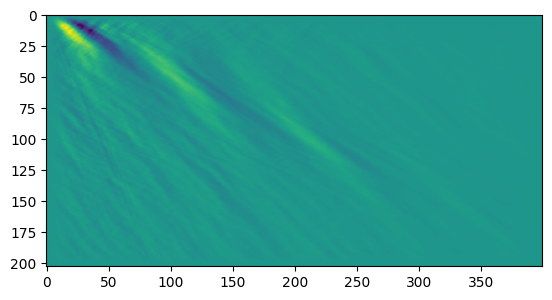

In [1183]:
plt.imshow(data)

In [1184]:
nt = data.shape[1]
dt = 1/25
nyq_f = nt//2  

freq =  np.fft.fftfreq(nt, d=dt)[slice(0,nyq_f)]

In [1185]:
# nx = data.shape[0]
# dx = 5.1 * 5
# nyq_k = nx//2

In [1186]:
fft_vals = np.fft.fft(data,axis=-1)

cross_real = np.real(fft_vals)[:,:len(freq)]

distlist = np.abs(np.arange(start_ch-vs_ch,end_ch-vs_ch) * 5 * 5.1 / 1000)
phase_search = np.arange(0.1,3,0.01)

In [1187]:
nfreq = len(freq)
nccr = len(distlist)
nphase = len(phase_search)

misfit = np.zeros([nfreq,nphase])

for ifreq in trange(nfreq):
    cross_obs = cross_real[:,ifreq]
    f = freq[ifreq]
    
    cost_list,Amp_search,syn_spac_search = grid_search_fitting_rayleigh(f,cross_obs,distlist,phase_search)
    misfit[ifreq,:] = cost_list[:]

  0%|          | 0/200 [00:00<?, ?it/s]

In [1189]:
# normalized misfit at each frequency
phase = phase_search

for ifreq in range(nfreq):
    maxv = np.max( np.abs( misfit[ifreq,:] ))
    misfit[ifreq,:] = misfit[ifreq,:] /maxv

In [897]:
# best_phase_velocity = phase[np.argmin(misfit,axis=1)]

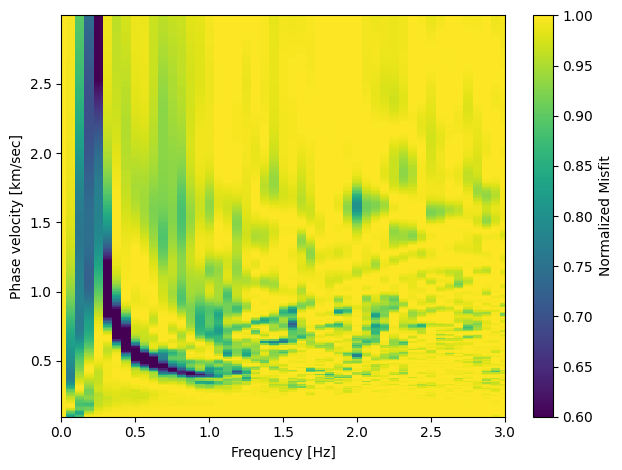

In [1190]:


# mk figure
fig = plt.figure(dpi=100)
ax = fig.add_subplot()
vmin = 0.6
vmax = 1.0
norm = colors.Normalize(vmin=vmin, vmax=vmax)
freqgrid,phasegrid = np.meshgrid(freq,phase)
bar = ax.pcolormesh(freqgrid,phasegrid,misfit.T,shading='nearest',cmap="viridis",norm=norm)

best_phase_velocity = phase[np.argmin(misfit,axis=1)]
# plt.plot(freq,best_phase_velocity,'r-',linewidth=2)

plt.xlim([0,3])

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Phase velocity [km/sec]")


h = plt.colorbar(bar)

h.set_label('Normalized Misfit')

plt.tight_layout()

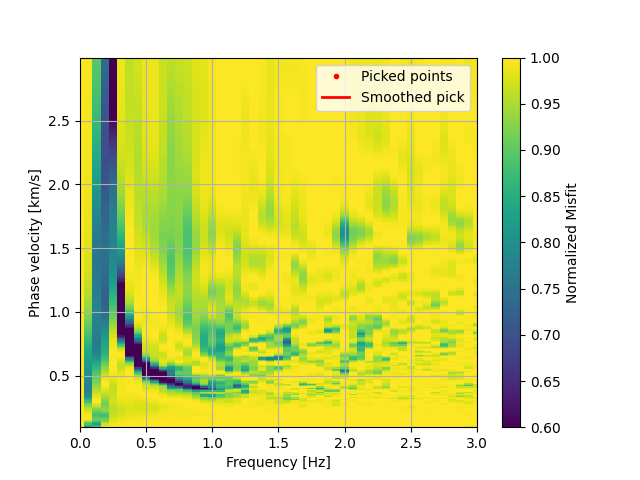

In [1191]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import ipywidgets as widgets

from scipy.interpolate import UnivariateSpline

# freq, phase, misfit = ...
fig, ax = plt.subplots(dpi=100)
vmin, vmax = 0.6, 1.0
norm = colors.Normalize(vmin=vmin, vmax=vmax)
freqgrid, phasegrid = np.meshgrid(freq, phase)
pcm = ax.pcolormesh(freqgrid, phasegrid, misfit.T, shading='nearest', cmap='viridis', norm=norm)
cb = plt.colorbar(pcm); cb.set_label('Normalized Misfit')

plt.grid()
ax.set_xlim([0, 3])
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Phase velocity [km/s]")

# --- interactive lines/points ---
picked_points = []
line_raw,   = ax.plot([], [], 'r.',  ms=6, label='Picked points')
line_smooth,= ax.plot([], [], 'r-',  lw=2, label='Smoothed pick')
ax.legend(loc='upper right')

def redraw():
    """Recompute spline and redraw the smooth curve if we have enough points."""
    if len(picked_points) < max(4, k_slider.value + 1):  # need >= k+1 points
        line_smooth.set_data([], [])
        fig.canvas.draw_idle()
        return
    
    # sort by frequency (x)
    pts = np.array(picked_points)
    x, y = pts[:,0], pts[:,1]
    order = np.argsort(x)
    x, y = x[order], y[order]

    # build spline; s ~ smoothness (0 -> interpolate all points)
    try:
        spl = UnivariateSpline(x, y, k=k_slider.value, s=s_slider.value)
        x_dense = np.linspace(x.min(), x.max(), npts_slider.value)
        y_dense = spl(x_dense)
        line_smooth.set_data(x_dense, y_dense)
    except Exception as e:
        # if fit fails (rare), clear the smooth line
        line_smooth.set_data([], [])
    fig.canvas.draw_idle()

def onclick(event):
    if event.inaxes != ax: return
    picked_points.append((event.xdata, event.ydata))
    xs, ys = zip(*picked_points)
    line_raw.set_data(xs, ys)
    redraw()

def clear_points(_):
    picked_points.clear()
    line_raw.set_data([], [])
    line_smooth.set_data([], [])
    fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect('button_press_event', onclick)

# --- Controls ---
s_slider = widgets.FloatLogSlider(
    value=1e-4, base=10, min=-8, max=0, step=0.25,
    description='smooth (s)', readout_format='.1e', continuous_update=False
)
k_slider = widgets.IntSlider(value=3, min=1, max=5, step=1, description='order (k)')

npts_slider = widgets.IntSlider(value=300, min=100, max=1000, step=50, description='N pts')

update_btn = widgets.Button(description="Fit / Update", button_style='primary')
clear_btn  = widgets.Button(description="Clear", button_style='danger')

update_btn.on_click(lambda _: redraw())
clear_btn.on_click(clear_points)
widgets.jslink((s_slider, 'value'), (s_slider, 'value'))  # no-op, just to keep widget alive

ui = widgets.HBox([s_slider, k_slider, npts_slider, update_btn, clear_btn])
display(ui)

# --- optional: save after you’re happy ---
def get_smoothed_curve():
    """Return (x_dense, y_dense) of the current smooth curve; empty arrays if not fitted."""
    xd, yd = line_smooth.get_xdata(), line_smooth.get_ydata()
    return np.array(xd), np.array(yd)

# Example:
# x_fit, y_fit = get_smoothed_curve()
# np.savez('picked_dispersion_smooth.npz', freq=x_fit, vel=y_fit)


In [1192]:
x_fit, y_fit = get_smoothed_curve()

In [1193]:
x_fit.shape

(150,)

In [ ]:
# read_data = np.load('/home/gcl/RA/yuancong_gou/github/clone/BSL_DAS/MARS/surface_waves_dispersion/data/dispersion_data_'+str(start_ch)+'_'+str(end_ch)+'_'+str(vs_ch)+'_picked_dispersion_smoothed_m1_q1.npz')

In [ ]:
# x_fit = read_data['freq']
# y_fit = read_data['phase_vel']

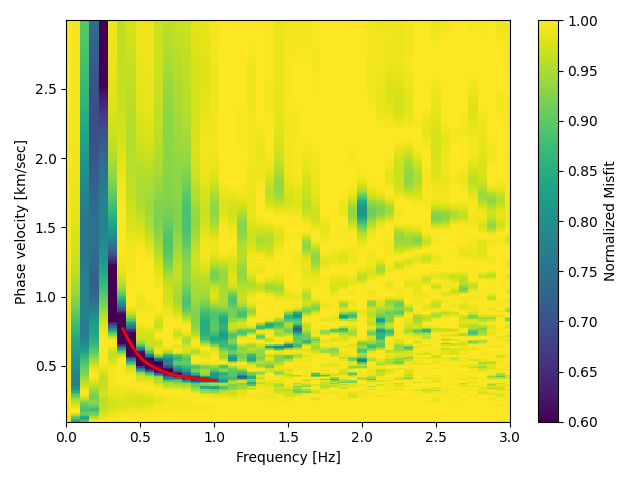

In [1194]:
fig = plt.figure(dpi=100)
ax = fig.add_subplot()
vmin = 0.6
vmax = 1.0
norm = colors.Normalize(vmin=vmin, vmax=vmax)
freqgrid,phasegrid = np.meshgrid(freq,phase)
bar = ax.pcolormesh(freqgrid,phasegrid,misfit.T,shading='nearest',cmap="viridis",norm=norm)

# plt.plot(np.array(picked_points)[:,0],np.array(picked_points)[:,1],'r-',linewidth=2)
plt.plot(x_fit, y_fit,'r-',linewidth=2)

plt.xlim([0,3])

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Phase velocity [km/sec]")


h = plt.colorbar(bar)

h.set_label('Normalized Misfit')

plt.tight_layout()

In [1196]:
# fundemental mode

# q1
# np.savez('/home/gcl/RA/yuancong_gou/github/clone/BSL_DAS/MARS/surface_waves_dispersion/data/dispersion_data_'+str(start_ch)+'_'+str(end_ch)+'_'+str(vs_ch)+'_picked_dispersion_smoothed_m0_q1.npz', freq=x_fit, phase_vel=y_fit)

# q2
# np.savez('/home/gcl/RA/yuancong_gou/github/clone/BSL_DAS/MARS/surface_waves_dispersion/data/dispersion_data_'+str(start_ch)+'_'+str(end_ch)+'_'+str(vs_ch)+'_picked_dispersion_smoothed_m0_q2.npz', freq=x_fit, phase_vel=y_fit)

# q3
# np.savez('/home/gcl/RA/yuancong_gou/github/clone/BSL_DAS/MARS/surface_waves_dispersion/data/dispersion_data_'+str(start_ch)+'_'+str(end_ch)+'_'+str(vs_ch)+'_picked_dispersion_smoothed_m0_q3.npz', freq=x_fit, phase_vel=y_fit)

# q4
# np.savez('/home/gcl/RA/yuancong_gou/github/clone/BSL_DAS/MARS/surface_waves_dispersion/data/dispersion_data_'+str(start_ch)+'_'+str(end_ch)+'_'+str(vs_ch)+'_picked_dispersion_smoothed_m0_q4.npz', freq=x_fit, phase_vel=y_fit)

In [ ]:
# first overtone

# q1
# np.savez('/home/gcl/RA/yuancong_gou/github/clone/BSL_DAS/MARS/surface_waves_dispersion/data/dispersion_data_'+str(start_ch)+'_'+str(end_ch)+'_'+str(vs_ch)+'_picked_dispersion_smoothed_m1_q1.npz', freq=x_fit, phase_vel=y_fit)

# q2
# np.savez('/home/gcl/RA/yuancong_gou/github/clone/BSL_DAS/MARS/surface_waves_dispersion/data/dispersion_data_'+str(start_ch)+'_'+str(end_ch)+'_'+str(vs_ch)+'_picked_dispersion_smoothed_m1_q2.npz', freq=x_fit, phase_vel=y_fit)

# q3
# np.savez('/home/gcl/RA/yuancong_gou/github/clone/BSL_DAS/MARS/surface_waves_dispersion/data/dispersion_data_'+str(start_ch)+'_'+str(end_ch)+'_'+str(vs_ch)+'_picked_dispersion_smoothed_m1_q3.npz', freq=x_fit, phase_vel=y_fit)

# q4
# np.savez('/home/gcl/RA/yuancong_gou/github/clone/BSL_DAS/MARS/surface_waves_dispersion/data/dispersion_data_'+str(start_ch)+'_'+str(end_ch)+'_'+str(vs_ch)+'_picked_dispersion_smoothed_m1_q4.npz', freq=x_fit, phase_vel=y_fit)

In [27]:
import numpy as np
from typing import Optional

def pick_smooth_phase_velocity(
    misfit: np.ndarray,   # shape: (n_freq, n_phase) -> misfit[f, p]
    phase: np.ndarray,    # shape: (n_phase,)
    freq: np.ndarray,     # shape: (n_freq,)
    lam: float = 5.0,     # smoothness weight (bigger = smoother)
    slope_limit: Optional[float] = None  # optional: max |dV/df| in km/s/Hz
):
    """
    Returns:
        best_v (n_freq,): picked phase velocity
        idx_path (n_freq,): indices into phase
    """
    nF, nP = misfit.shape
    # Precompute pairwise transition cost between phase bins (quadratic in jump size)
    dV = phase[:, None] - phase[None, :]    # (p, p): from prev j to curr i -> i - j
    trans_base = dV**2                      # L2 smoothness on velocity jumps

    # Optional slope constraint: mask impossible jumps by +inf
    if slope_limit is not None and nF > 1:
        df = np.diff(freq)
        # For each step k, allowable |ΔV| = slope_limit * df[k]
        slope_masks = []
        for k in range(nF-1):
            allowed = slope_limit * df[k]
            mask = np.where(np.abs(dV) <= allowed, 0.0, np.inf)
            slope_masks.append(mask)
    else:
        slope_masks = [np.zeros_like(trans_base)] * (nF-1)

    # DP arrays
    C = np.full((nF, nP), np.inf)  # cumulative cost
    bp = np.full((nF, nP), -1, dtype=int)  # backpointers

    # init at first frequency
    C[0] = misfit[0]

    # forward pass
    for k in range(1, nF):
        # transition cost from any prev j -> current i
        trans_cost = lam * (trans_base + slope_masks[k-1])  # (p, p)
        # prev cumulative + transition: shape (p_prev, p_curr)
        total = C[k-1][:, None] + trans_cost
        # take min over prev phase index
        j_min = np.argmin(total, axis=0)
        C[k] = misfit[k] + total[j_min, np.arange(nP)]
        bp[k] = j_min

    # backtrack
    idx_last = int(np.argmin(C[-1]))
    idx_path = np.empty(nF, dtype=int)
    idx_path[-1] = idx_last
    for k in range(nF-2, -1, -1):
        idx_path[k] = bp[k+1, idx_path[k+1]]

    best_v = phase[idx_path]

    # Optional: sub-bin parabolic refinement around each picked index
    # (fits a quadratic to the local misfit in phase bins i-1, i, i+1)
    v_refined = best_v.astype(float).copy()
    for k in range(nF):
        i = idx_path[k]
        if 0 < i < nP-1:
            y1, y2, y3 = misfit[k, i-1], misfit[k, i], misfit[k, i+1]
            x1, x2, x3 = phase[i-1], phase[i], phase[i+1]
            # vertex of parabola through three points
            denom = (x1 - x2)*(x1 - x3)*(x2 - x3)
            if denom != 0:
                A = (x3*(y2 - y1) + x2*(y1 - y3) + x1*(y3 - y2)) / denom
                B = (x3**2*(y1 - y2) + x2**2*(y3 - y1) + x1**2*(y2 - y3)) / denom
                xv = -B/(2*A) if A != 0 else x2
                # clamp inside neighbors to avoid runaway
                if min(x1, x3) <= xv <= max(x1, x3):
                    v_refined[k] = xv

    return v_refined, idx_path


In [28]:
%matplotlib inline

In [29]:
best_v_smooth, idx_path = pick_smooth_phase_velocity(
    misfit=misfit,
    phase=phase,
    freq=freq,
    lam=20.0,              # try 1–20; increase for smoother curves
    slope_limit=0.6       # km/s per Hz (optional guard on unrealistic jumps)
)



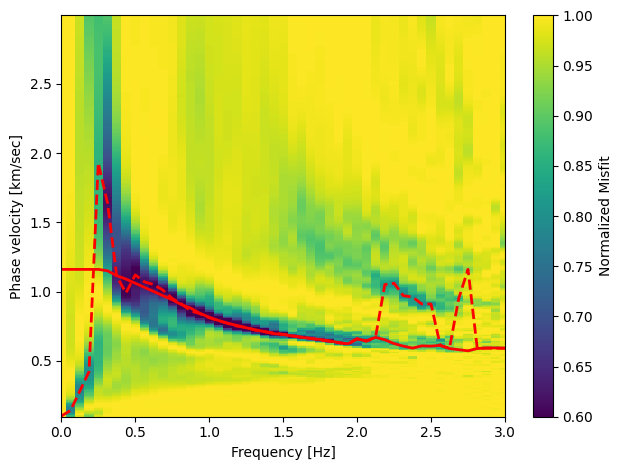

In [30]:
fig = plt.figure(dpi=100)
ax = fig.add_subplot()
vmin = 0.6
vmax = 1.0
norm = colors.Normalize(vmin=vmin, vmax=vmax)
freqgrid,phasegrid = np.meshgrid(freq,phase)
bar = ax.pcolormesh(freqgrid,phasegrid,misfit.T,shading='nearest',cmap="viridis",norm=norm)

plt.plot(freq,best_v_smooth,'r-',linewidth=2)
plt.plot(freq,best_phase_velocity,'r--',linewidth=2)

plt.xlim([0,3])

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Phase velocity [km/sec]")


h = plt.colorbar(bar)

h.set_label('Normalized Misfit')

plt.tight_layout()

In [69]:
best_phase_velocity.shape

(200,)

In [71]:
freq.shape

(200,)

In [31]:
dispersion_data = np.vstack((freq,best_v_smooth)).T

In [32]:
dispersion_data.shape

(200, 2)

In [ ]:
# np.save('/home/gcl/RA/yuancong_gou/github/clone/BSL_DAS/MARS/surface_waves_dispersion/data/dispersion_data_'+str(start_ch)+'_'+str(end_ch)+'_'+str(vs_ch)+'.npy',dispersion_data)

In [17]:
nfreq

200

In [ ]:
nfreq = len(freq)
nccr = len(distlist)
nphase = len(phase_search)

misfit = np.zeros([nfreq,nphase])
run = sub_spac_das.fit_spac_strain()
for ifreq in range(nfreq):
    cross_obs = cross_real[:,ifreq]
    f = freq[ifreq]
    
    cost_list,Amp_search,syn_spac_search = run.grid_search_fitting_rayleigh(f,cross_obs,distlist,phase_search)
    misfit[ifreq,:] = cost_list[:]

In [41]:
ccs = np.load('data_cross-spectra/cross_real.npy')

In [42]:
ccs.shape

(190, 214)

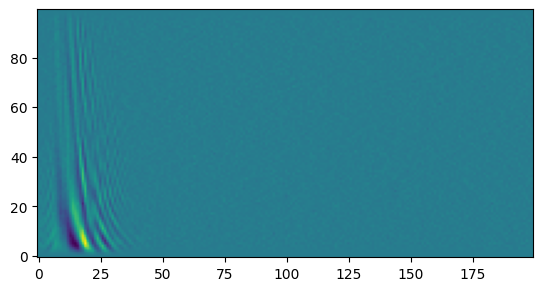

In [51]:
plt.imshow(cross_real,origin='lower')

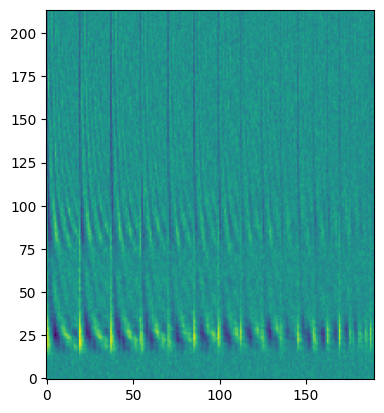

In [43]:
plt.imshow(ccs.T,origin='lower')

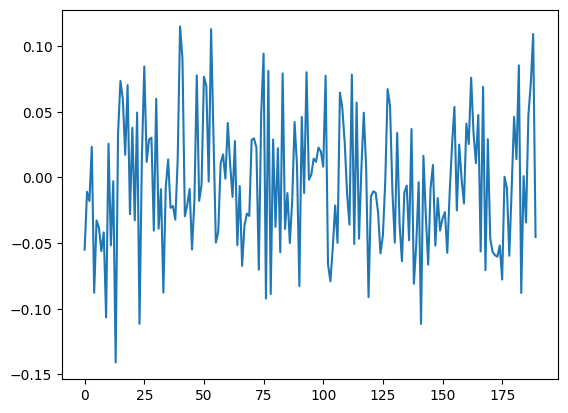

In [9]:
plt.plot(ccs[:,10])